# Capstone Project: Satellite Image Segmentation using U-Net

## Project Overview
This project addresses the task of semantic image segmentation—predicting a pixel-wise mask for an input image.
We implement the classic **U-Net architecture** from scratch in PyTorch to segment **building footprints** from real aerial imagery.

**Dataset:** [Massachusetts Buildings Dataset](https://www.kaggle.com/datasets/balraj98/massachusetts-buildings-dataset) (Mnih, 2013) — 151 aerial images of the Boston area (1500x1500 px each) with pixel-level building masks.

**Key Objectives:**
1. Implement a custom U-Net with Encoder (contracting path) and Decoder (expansive path) with skip connections.
2. Utilize Dice/IoU-friendly Cross-Entropy Loss and IoU (Intersection over Union) as evaluation metrics suitable for segmentation tasks.
3. Train and validate the model on a **real geospatial dataset** to demonstrate an end-to-end pipeline: data acquisition -> preprocessing -> training -> evaluation -> visualization.

## Завантаження реального датасету (Massachusetts Buildings Dataset) та підготовка DataLoader-ів


Using device: cuda


100%|██████████| 1.49G/1.49G [01:18<00:00, 20.4MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/balraj98/massachusetts-buildings-dataset/versions/2
train images: /root/.cache/kagglehub/datasets/balraj98/massachusetts-buildings-dataset/versions/2/png/train
train masks:  /root/.cache/kagglehub/datasets/balraj98/massachusetts-buildings-dataset/versions/2/png/train_labels
val images:   /root/.cache/kagglehub/datasets/balraj98/massachusetts-buildings-dataset/versions/2/png/val
val masks:    /root/.cache/kagglehub/datasets/balraj98/massachusetts-buildings-dataset/versions/2/png/val_labels
Train samples: 137, Val samples: 4


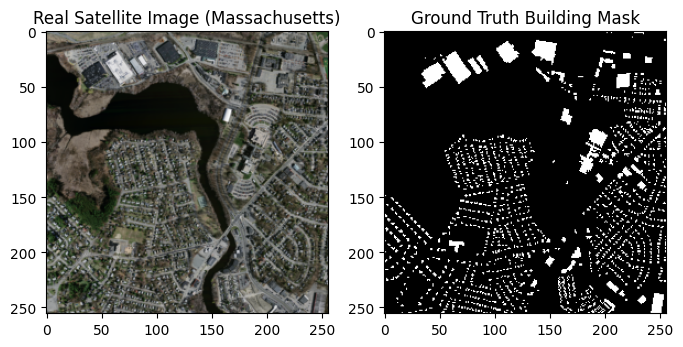

In [1]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Завантаження РЕАЛЬНОГО датасету супутникових знімків з Kaggle
#    Massachusetts Buildings Dataset: 151 аерофото Бостона (1500x1500 px) + маски будівель
!pip install -q kagglehub

import kagglehub
dataset_path = kagglehub.dataset_download("balraj98/massachusetts-buildings-dataset")
print("Dataset downloaded to:", dataset_path)

# Датасет може мати різну структуру папок залежно від версії (png/train, tiff/train, тощо),
# тож знаходимо потрібні директорії автоматично, а не хардкодимо шлях.
def find_dir(root, name):
    for dirpath, dirnames, _ in os.walk(root):
        if name in dirnames:
            return os.path.join(dirpath, name)
    raise FileNotFoundError(f"Не знайдено директорію '{name}' у {root}")

train_img_dir = find_dir(dataset_path, "train")
train_mask_dir = find_dir(dataset_path, "train_labels")
val_img_dir = find_dir(dataset_path, "val")
val_mask_dir = find_dir(dataset_path, "val_labels")

print("train images:", train_img_dir)
print("train masks: ", train_mask_dir)
print("val images:  ", val_img_dir)
print("val masks:   ", val_mask_dir)

IMG_SIZE = 256  # зменшуємо з 1500x1500 до розумного розміру для швидкого навчання

class SatelliteDataset(Dataset):
    """Реальні аерофото + бінарні маски будівель (Massachusetts Buildings Dataset)."""

    def __init__(self, img_dir, mask_dir, size=IMG_SIZE):
        # Збираємо шляхи до зображень (розширення можуть бути .png/.tif/.tiff)
        exts = ("*.png", "*.tif", "*.tiff", "*.jpg", "*.jpeg")
        self.img_paths = []
        for e in exts:
            self.img_paths.extend(glob.glob(os.path.join(img_dir, e)))
        self.img_paths = sorted(self.img_paths)
        if len(self.img_paths) == 0:
            raise RuntimeError(f"У {img_dir} не знайдено жодного зображення")

        self.mask_dir = mask_dir
        self.size = size

    def __len__(self):
        return len(self.img_paths)

    def _match_mask(self, img_path):
        # Маска зазвичай має ту саму назву файлу (можливо, інше розширення)
        base = os.path.splitext(os.path.basename(img_path))[0]
        candidates = glob.glob(os.path.join(self.mask_dir, base + ".*"))
        if not candidates:
            raise FileNotFoundError(f"Не знайдено маску для {img_path}")
        return candidates[0]

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        mask_path = self._match_mask(img_path)

        img = Image.open(img_path).convert("RGB").resize((self.size, self.size), Image.BILINEAR)
        mask = Image.open(mask_path).convert("L").resize((self.size, self.size), Image.NEAREST)

        img_arr = np.array(img).astype(np.float32) / 255.0
        mask_arr = (np.array(mask) > 127).astype(np.int64)  # 0 - фон, 1 - будівля

        img_tensor = torch.from_numpy(img_arr).permute(2, 0, 1)
        mask_tensor = torch.from_numpy(mask_arr)

        return img_tensor, mask_tensor

# Створення DataLoader-ів на реальних даних
train_dataset = SatelliteDataset(train_img_dir, train_mask_dir)
val_dataset = SatelliteDataset(val_img_dir, val_mask_dir)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

# Візуалізація прикладу з реального датасету
img, msk = train_dataset[0]
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img.permute(1, 2, 0))
ax[0].set_title("Real Satellite Image (Massachusetts)")
ax[1].imshow(msk, cmap='gray')
ax[1].set_title("Ground Truth Building Mask")
plt.show()

## Реалізація архітектури U-Net

In [2]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=2): # 2 класи: фон та будівля
        super().__init__()
        # Encoder (Down)
        self.inc = DoubleConv(in_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))

        # Decoder (Up)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv_up1 = DoubleConv(128, 64) # 64 (від up1) + 64 (від skip connection down1)

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv_up2 = DoubleConv(64, 32)  # 32 + 32

        self.outc = nn.Conv2d(32, out_channels, 1)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)

        # Decoder з додаванням Skip Connections
        out = self.up1(x3)
        out = torch.cat([out, x2], dim=1)
        out = self.conv_up1(out)

        out = self.up2(out)
        out = torch.cat([out, x1], dim=1)
        out = self.conv_up2(out)

        return self.outc(out)

model = UNet().to(device)
print("U-Net Model Initialized.")

U-Net Model Initialized.


## Функція оцінки метрики IoU та Навчання

In [3]:
def compute_iou(preds, labels):
    # Метрика IoU для оцінки якості сегментації
    preds = torch.argmax(preds, dim=1)
    intersection = (preds & labels).float().sum((1, 2))
    union = (preds | labels).float().sum((1, 2))
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 15  # реальні дані складніші за синтетичні -> трохи більше епох
history = {'train_loss': [], 'val_loss': [], 'val_iou': []}

print("--- Starting U-Net Training ---")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

    # Валідація
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)
            val_iou += compute_iou(outputs, masks) * images.size(0)

    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val IoU: {val_iou:.4f}")

--- Starting U-Net Training ---
Epoch 1/15 | Train Loss: 0.7671 | Val Loss: 0.5625 | Val IoU: 0.0066
Epoch 2/15 | Train Loss: 0.5406 | Val Loss: 0.3921 | Val IoU: 0.0076
Epoch 3/15 | Train Loss: 0.4341 | Val Loss: 0.3337 | Val IoU: 0.0889
Epoch 4/15 | Train Loss: 0.3672 | Val Loss: 0.2925 | Val IoU: 0.3064
Epoch 5/15 | Train Loss: 0.3288 | Val Loss: 0.2711 | Val IoU: 0.3635
Epoch 6/15 | Train Loss: 0.3050 | Val Loss: 0.2484 | Val IoU: 0.3434
Epoch 7/15 | Train Loss: 0.2918 | Val Loss: 0.2354 | Val IoU: 0.3569
Epoch 8/15 | Train Loss: 0.2786 | Val Loss: 0.2254 | Val IoU: 0.3704
Epoch 9/15 | Train Loss: 0.2706 | Val Loss: 0.2164 | Val IoU: 0.3734
Epoch 10/15 | Train Loss: 0.2596 | Val Loss: 0.2224 | Val IoU: 0.4161
Epoch 11/15 | Train Loss: 0.2585 | Val Loss: 0.2047 | Val IoU: 0.3701
Epoch 12/15 | Train Loss: 0.2517 | Val Loss: 0.2123 | Val IoU: 0.3672
Epoch 13/15 | Train Loss: 0.2505 | Val Loss: 0.1960 | Val IoU: 0.3566
Epoch 14/15 | Train Loss: 0.2454 | Val Loss: 0.1939 | Val IoU: 0.41

## Візуалізація результатів сегментації

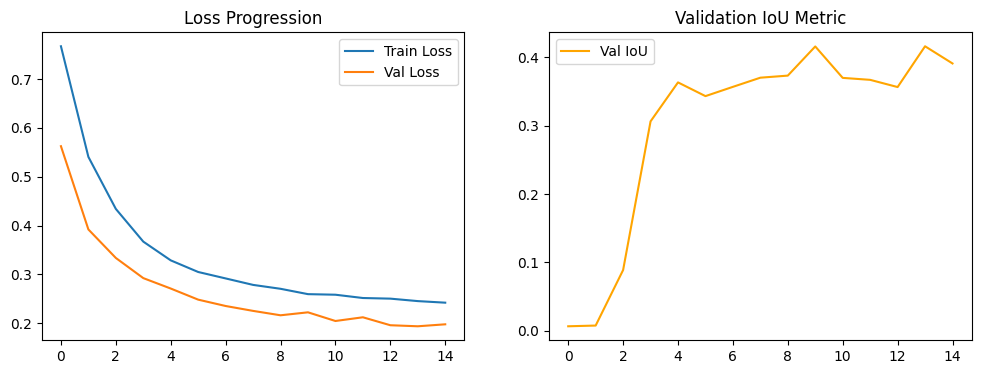

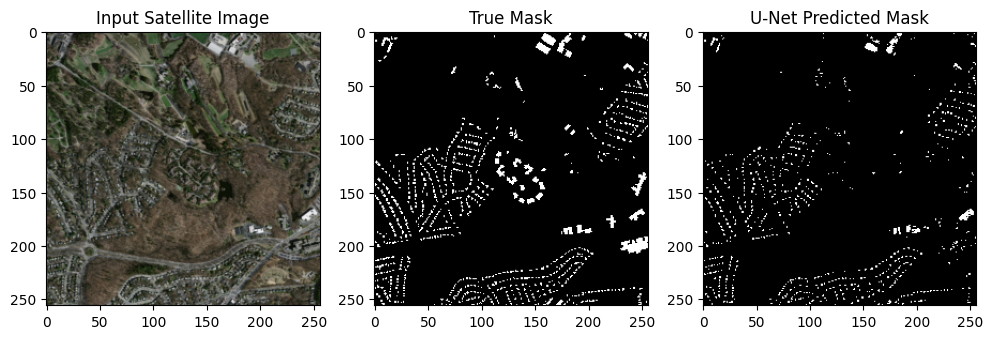

In [4]:
# Графік навчання
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Progression')

plt.subplot(1, 2, 2)
plt.plot(history['val_iou'], label='Val IoU', color='orange')
plt.legend()
plt.title('Validation IoU Metric')
plt.show()

# Візуалізація результату на тестовому прикладі
model.eval()
images, masks = next(iter(val_loader))
with torch.no_grad():
    outputs = model(images.to(device))
    preds = torch.argmax(outputs, dim=1).cpu()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(images[0].permute(1, 2, 0))
ax[0].set_title("Input Satellite Image")
ax[1].imshow(masks[0], cmap='gray')
ax[1].set_title("True Mask")
ax[2].imshow(preds[0], cmap='gray')
ax[2].set_title("U-Net Predicted Mask")
plt.show()